In [6]:
%pip install requests rdkit imbalanced-learn seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1782330793.748599   25519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.labelsize': 11, 'axes.titlesize': 13})

In [13]:
df_raw = pd.read_csv('/home/bedanga-b-bora/Downloads/pubchem_geneid_1588_bioactivity_gene.csv')
df_raw.head()

,baid,Aid_Type,Activity,Protein_Accession,Activity_Type,Activity_Qualifier,Bioassay_Data_Source,BioAssay_Name,Compound_Name,Target_Name,...,refsid,Gene_ID,PMID,Last_Modified_Date,Has_Dose_Response_Curve,RNAi_BioAssay,Activity_Value,Taxonomy_ID,Target_Taxonomy_ID,Anatomy_ID
0,380382372,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,(+-)-Naringenin,CYP19A1 - cytochrome P450 family 19 subfamily ...,...,NaN,1588,22726671.0,20241112,0,0,0.000001,9606,NaN,NaN
1,380382375,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"8-(4-hydroxy-3,5-dimethoxyphenyl)-7,8-dihydro-...",CYP19A1 - cytochrome P450 family 19 subfamily ...,...,NaN,1588,22726671.0,20241112,0,0,0.000002,9606,NaN,NaN
2,380382378,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"8-(3,4,5-trimethoxyphenyl)-7,8-dihydro-6H-[1,3...",CYP19A1 - cytochrome P450 family 19 subfamily ...,...,NaN,1588,22726671.0,20241112,0,0,0.000002,9606,NaN,NaN
3,380382379,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"Neoflavonoid, 9",CYP19A1 - cytochrome P450 family 19 subfamily ...,...,NaN,1588,22726671.0,20241112,0,0,0.000003,9606,NaN,NaN
4,355596189,Confirmatory,Active,P11511,IC50,=,ChEMBL,Inhibition of aromatase (unknown origin) trans...,Fadrozole,CYP19A1 - cytochrome P450 family 19 subfamily ...,...,NaN,1588,26689671.0,20220830,0,0,0.000004,9606,NaN,NaN


In [14]:
df_ic50 = df_raw[df_raw['Activity_Type'] == 'IC50'].copy()
df_ic50 = df_ic50.dropna(subset=['Activity_Value', 'Compound_CID'])
print(f"Filtered quantitative IC50 dataset shape: {df_ic50.shape}")

Filtered quantitative IC50 dataset shape: (4554, 32)


Time for Exploratory Data Analysis in VS Code as my internet is trash

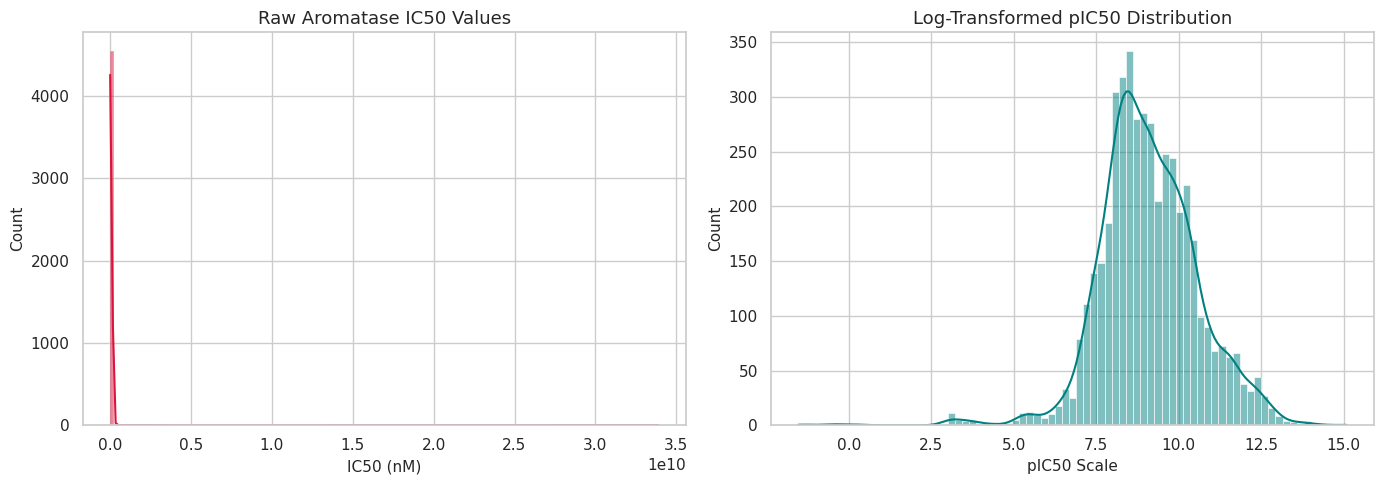

Potency Statistics for pIC50:
 count    4554.000000
mean        9.091795
std         1.496337
min        -1.530000
25%         8.190194
50%         9.000000
75%        10.000000
max        15.091515
Name: pIC50, dtype: float64


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_ic50['Activity_Value'], kde=True, color='crimson', ax=ax[0])
ax[0].set_title("Raw Aromatase IC50 Values")
ax[0].set_xlabel("IC50 (nM)")
df_ic50['pIC50'] = -np.log10(df_ic50['Activity_Value'] * 1e-9)
sns.histplot(df_ic50['pIC50'], kde=True, color='teal', ax=ax[1])
ax[1].set_title("Log-Transformed pIC50 Distribution")
ax[1].set_xlabel("pIC50 Scale")
plt.tight_layout()
plt.show()
print("Potency Statistics for pIC50:\n", df_ic50['pIC50'].describe())

**EDA Insight:** The raw concentration numbers show extreme positive skewing. Transforming the 
# values to a logarithmic scale ($pIC_{50}$) normalizes the distribution, creating a stable, continuous 
# metric suitable for establishing balanced median sorting thresholds.

MEDIAN TARGET SPLITTING

In [22]:
df_sorted = df_ic50.sort_values(by='pIC50', ascending=False).reset_index(drop=True)
mid_point = len(df_sorted) // 2

df_sorted['target'] = 0
df_sorted.iloc[:mid_point, df_sorted.columns.get_loc('target')] = 1

In [23]:
print(f"Target vector allocation:\n{df_sorted['target'].value_counts()}")

Target vector allocation:
target
1    2277
0    2277
Name: count, dtype: int64


BIOASSAY CONTEXTUAL TEXT PROFILING

It feels like Manual Labour without access to Claude due to Internet

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
df_sorted['BioAssay_Name'] = df_sorted['BioAssay_Name'].fillna('Unknown')
tfidf = TfidfVectorizer(max_features=10, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_sorted['BioAssay_Name'])

In [27]:
for word in tfidf.get_feature_names_out():
    print(f" - {word}")

 - 3h
 - aromatase
 - human
 - incubated
 - inhibition
 - measured
 - mins
 - placental
 - substrate
 - using


Finally the internet is backkkk

In [32]:
# 1. Clear out invalid or zeroed bioactivity measurements
df_clean_ic50 = df_ic50[df_ic50['Activity_Value'] > 0].copy()

# 2. Compute true molar log potency scale (assuming nanomolar units)
df_clean_ic50['pIC50'] = -np.log10(df_clean_ic50['Activity_Value'] * 1e-9)

# 3. Sort by genuine highest potency down to lowest potency
df_sorted = df_clean_ic50.sort_values(by='pIC50', ascending=False).reset_index(drop=True)

# 4. Apply the median split boundary
mid_point = len(df_sorted) // 2
df_sorted['target'] = 0
df_sorted.iloc[:mid_point, df_sorted.columns.get_loc('target')] = 1

print("Data points successfully adjusted and verified:")
print(df_sorted['target'].value_counts())

Data points successfully adjusted and verified:
target
1    2277
0    2277
Name: count, dtype: int64


PUBCHEM PUG-REST STRUCTURE RETRIEVAL

In [39]:
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, MACCSkeys, AllChem
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Suppress annoying warning logs
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
print("Setup complete")

# --- FILE INGESTION LAYER ---
# Explicitly matching your local file name
DATA_FILE_NAME = "/home/bedanga-b-bora/Downloads/pubchem_geneid_1588_bioactivity_gene.csv"

print(f"Loading local dataset: {DATA_FILE_NAME}...")
model_df_unique = pd.read_csv(DATA_FILE_NAME)

# Standardize column types: drop empty CIDs and force them to clean integers
model_df_unique = model_df_unique.dropna(subset=["Compound_CID"])
model_df_unique["Compound_CID"] = model_df_unique["Compound_CID"].astype(int)
print(f"Loaded main dataframe with shape: {model_df_unique.shape}")

# --- CACHING ENGINE ---
SMILES_CACHE_FILE = "cyp19a1_cid_smiles_cache.csv"

def fetch_smiles_from_pubchem(cid, sleep_time=0.04):
    try:
        compound = pcp.Compound.from_cid(int(cid))
        time.sleep(sleep_time)
        return compound.canonical_smiles
    except Exception:
        return np.nan

if os.path.exists(SMILES_CACHE_FILE):
    smiles_cache = pd.read_csv(SMILES_CACHE_FILE).dropna(subset=["SMILES"])
    smiles_cache["Compound_CID"] = smiles_cache["Compound_CID"].astype(int)
    print("Loaded existing cache file from disk:", smiles_cache.shape)
else:
    print("No existing cache found. Creating a fresh tracking cache.")
    smiles_cache = pd.DataFrame(columns=["Compound_CID", "SMILES"])

# Safe-drop old SMILES column if it accidentally carried over
model_df_unique = model_df_unique.drop(columns=["SMILES"], errors="ignore")

# Left-join to see which chemical structures we already know
model_df_unique = model_df_unique.merge(smiles_cache, on="Compound_CID", how="left")
missing_cids = model_df_unique.loc[model_df_unique["SMILES"].isna(), "Compound_CID"].unique().tolist()
print("Need to fetch SMILES for:", len(missing_cids), "unseen CIDs")

# --- LIVE API STREAMING ---
new_rows = []
for i, cid in enumerate(missing_cids, start=1):
    smi = fetch_smiles_from_pubchem(cid)
    new_rows.append({"Compound_CID": cid, "SMILES": smi})
    
    # Batch backup save every 100 entries to protect progress
    if i % 100 == 0:
        print(f"Fetched {i}/{len(missing_cids)}")
        temp_cache = pd.concat([smiles_cache, pd.DataFrame(new_rows)], ignore_index=True)
        temp_cache = temp_cache.dropna(subset=["SMILES"]).drop_duplicates(subset=["Compound_CID"])
        temp_cache.to_csv(SMILES_CACHE_FILE, index=False)

# Final cache synchronization and save
if new_rows:
    smiles_cache = pd.concat([smiles_cache, pd.DataFrame(new_rows)], ignore_index=True)
    smiles_cache = smiles_cache.dropna(subset=["SMILES"]).drop_duplicates(subset=["Compound_CID"])
    smiles_cache.to_csv(SMILES_CACHE_FILE, index=False)

# Re-merge to combine newly fetched structures cleanly with your dataset
model_df_unique = model_df_unique.drop(columns=["SMILES"], errors="ignore")
model_df_unique = model_df_unique.merge(smiles_cache, on="Compound_CID", how="left")

print("Rows before dropping missing SMILES:", len(model_df_unique))
model_df_unique = model_df_unique.dropna(subset=["SMILES"]).reset_index(drop=True)
print("Rows after dropping missing SMILES:", len(model_df_unique))

# Display structural results preview
display(model_df_unique.head())

Setup complete
Loading local dataset: /home/bedanga-b-bora/Downloads/pubchem_geneid_1588_bioactivity_gene.csv...
Loaded main dataframe with shape: (27827, 32)
No existing cache found. Creating a fresh tracking cache.
Need to fetch SMILES for: 11966 unseen CIDs
Fetched 100/11966
Fetched 200/11966
Fetched 300/11966
Fetched 400/11966
Fetched 500/11966
Fetched 600/11966
Fetched 700/11966
Fetched 800/11966
Fetched 900/11966
Fetched 1000/11966
Fetched 1100/11966
Fetched 1200/11966
Fetched 1300/11966
Fetched 1400/11966
Fetched 1500/11966
Fetched 1600/11966
Fetched 1700/11966
Fetched 1800/11966
Fetched 1900/11966
Fetched 2000/11966
Fetched 2100/11966
Fetched 2200/11966
Fetched 2300/11966
Fetched 2400/11966
Fetched 2500/11966
Fetched 2600/11966
Fetched 2700/11966
Fetched 2800/11966
Fetched 2900/11966
Fetched 3000/11966
Fetched 3100/11966
Fetched 3200/11966
Fetched 3300/11966
Fetched 3400/11966
Fetched 3500/11966
Fetched 3600/11966
Fetched 3700/11966
Fetched 3800/11966
Fetched 3900/11966
Fetched

,baid,Aid_Type,Activity,Protein_Accession,Activity_Type,Activity_Qualifier,Bioassay_Data_Source,BioAssay_Name,Compound_Name,Target_Name,Target_Link,ECs,Representative_Protein_Accession,Cell_ID,Anatomy,dois,pmcids,pclids,citations,BioAssay_AID,Substance_SID,Compound_CID,refsid,Gene_ID,PMID,Last_Modified_Date,Has_Dose_Response_Curve,RNAi_BioAssay,Activity_Value,Taxonomy_ID,Target_Taxonomy_ID,Anatomy_ID,SMILES
0,380382372,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,(+-)-Naringenin,CYP19A1 - cytochrome P450 family 19 subfamily ...,/gene/1588,1.14.14.14,P11511,NaN,NaN,10.1111/j.1747-0285.2012.01439.x,PMC3448855,26931148.0,"Luqman S, Meena A, Singh P, Kondratyuk TP, Mar...",1799798,46519482,932,NaN,1588,22726671.0,20241112,0,0,0.000001,9606,NaN,NaN,C1C(OC2=CC(=CC(=C2C1=O)O)O)C3=CC=C(C=C3)O
1,380382375,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"8-(4-hydroxy-3,5-dimethoxyphenyl)-7,8-dihydro-...",CYP19A1 - cytochrome P450 family 19 subfamily ...,/gene/1588,1.14.14.14,P11511,NaN,NaN,10.1111/j.1747-0285.2012.01439.x,PMC3448855,26931148.0,"Luqman S, Meena A, Singh P, Kondratyuk TP, Mar...",1799798,160845053,46177290,NaN,1588,22726671.0,20241112,0,0,0.000002,9606,NaN,NaN,COC1=CC(=CC(=C1O)OC)C2CC(=O)OC3=CC4=C(C=C23)OCO4
2,380382378,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"8-(3,4,5-trimethoxyphenyl)-7,8-dihydro-6H-[1,3...",CYP19A1 - cytochrome P450 family 19 subfamily ...,/gene/1588,1.14.14.14,P11511,NaN,NaN,10.1111/j.1747-0285.2012.01439.x,PMC3448855,26931148.0,"Luqman S, Meena A, Singh P, Kondratyuk TP, Mar...",1799798,160845052,17756877,NaN,1588,22726671.0,20241112,0,0,0.000002,9606,NaN,NaN,COC1=CC(=CC(=C1OC)OC)C2CC(=O)OC3=CC4=C(C=C23)OCO4
3,380382379,Confirmatory,Active,P11511,Ki,NaN,BindingDB,Aromatase Assay from Article 10.1111/j.1747-02...,"Neoflavonoid, 9",CYP19A1 - cytochrome P450 family 19 subfamily ...,/gene/1588,1.14.14.14,P11511,NaN,NaN,10.1111/j.1747-0285.2012.01439.x,PMC3448855,26931148.0,"Luqman S, Meena A, Singh P, Kondratyuk TP, Mar...",1799798,160845054,46177291,NaN,1588,22726671.0,20241112,0,0,0.000003,9606,NaN,NaN,CC(=O)OC1=C(C=C(C=C1OC)C2CC(=O)OC3=CC4=C(C=C23...
4,355596189,Confirmatory,Active,P11511,IC50,=,ChEMBL,Inhibition of aromatase (unknown origin) trans...,Fadrozole,CYP19A1 - cytochrome P450 family 19 subfamily ...,/gene/1588,1.14.14.14,P11511,31.0,NaN,10.1021/acs.jmedchem.5b01281,PMC4915572,12109458.0,"Ghosh D, Lo J, Egbuta C. Recent Progress in th...",1307752,103168211,59693,NaN,1588,26689671.0,20220830,0,0,0.000004,9606,NaN,NaN,C1CC(N2C=NC=C2C1)C3=CC=C(C=C3)C#N


In [40]:
print("Engineering chemical features from SMILES...")

# 1. Compute Physicochemical 2D Descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: 
        return [np.nan] * 4
    return [
        Descriptors.MolWt(mol),      # Molecular Weight
        Descriptors.MolLogP(mol),    # Octanol-water partition coefficient
        Descriptors.NumHDonors(mol),  # Hydrogen Bond Donors
        Descriptors.TPSA(mol)        # Topological Polar Surface Area
    ]

print(" -> Calculating physical property metrics...")
desc_data = [compute_descriptors(s) for s in model_df_unique['SMILES']]
df_desc = pd.DataFrame(desc_data, columns=['MolWt', 'LogP', 'HDonors', 'TPSA'], index=model_df_unique.index)
df_pipeline = pd.concat([model_df_unique, df_desc], axis=1).dropna(subset=['MolWt'])

# 2. Compute 2048-bit Morgan Fingerprints (ECFP4 Equivalent)
def compute_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))

print(" -> Generating structural bit vectors...")
X_fingerprints = np.array([compute_fingerprint(s) for s in df_pipeline['SMILES']])

# 3. Establish Binary Target Matrix (Median Split on Potency)
# Checking if target column or Activity_Value needs formatting
if 'target' not in df_pipeline.columns:
    # If not split yet, split by median of Activity_Value
    mid_thresh = df_pipeline['Activity_Value'].median()
    # Lower Activity_Value (IC50) means higher potency
    df_pipeline['target'] = (df_pipeline['Activity_Value'] <= mid_thresh).astype(int)

y = df_pipeline['target'].values
print(f"Feature processing complete. Matrix dimensions: {X_fingerprints.shape}")

Engineering chemical features from SMILES...
 -> Calculating physical property metrics...


[10:42:27] WARNING: not removing hydrogen atom without neighbors
[10:42:27] WARNING: not removing hydrogen atom without neighbors
[10:42:29] WARNING: not removing hydrogen atom without neighbors
[10:42:29] WARNING: not removing hydrogen atom without neighbors
[10:42:30] WARNING: not removing hydrogen atom without neighbors
[10:42:31] WARNING: not removing hydrogen atom without neighbors


 -> Generating structural bit vectors...


[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerator
[10:42:32] DEPRECATION WARNING: please use MorganGenerat

Feature processing complete. Matrix dimensions: (27381, 2048)


In [41]:
print("Partitioning and preparing datasets...")

# Stratified 80/20 train/test split to preserve activity ratios
X_train, X_test, y_train, y_test = train_test_split(
    X_fingerprints, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Apply low-variance threshold filtering to drop structural bits that are always 0 or 1
selector = VarianceThreshold(threshold=0.01)
X_train_filtered = selector.fit_transform(X_train)
X_test_filtered = selector.transform(X_test)

# Condense high-dimensional bits using PCA while keeping 90% descriptive variance
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_filtered)
X_test_pca = pca.transform(X_test_filtered)

print(f" -> Condensed fingerprint feature columns from {X_train.shape[1]} down to {X_train_pca.shape[1]}")

Partitioning and preparing datasets...
 -> Condensed fingerprint feature columns from 2048 down to 282


In [43]:
print("Initializing model competitive screening grid...\n")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "XGBoost Classifier": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

benchmark_metrics = []

for name, model in models.items():
    print(f" -> Training {name}...")
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)
    probs = model.predict_proba(X_test_pca)[:, 1]
    
    benchmark_metrics.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

# Format and display the competitive leaderboard matrix
df_leaderboard = pd.DataFrame(benchmark_metrics)
print("MODEL SCREENING LEADERBOARD")
display(df_leaderboard.sort_values(by="F1-Score", ascending=False).reset_index(drop=True))

Initializing model competitive screening grid...

 -> Training Logistic Regression...
 -> Training Random Forest...
 -> Training Support Vector Machine...
 -> Training XGBoost Classifier...
MODEL SCREENING LEADERBOARD


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Support Vector Machine,0.925507,0.788200,0.660330,0.718621,0.928184
1,XGBoost Classifier,0.912361,0.717300,0.646388,0.680000,0.936526
2,Random Forest,0.911265,0.721168,0.626109,0.670285,0.926557
3,Logistic Regression,0.907796,0.723270,0.583016,0.645614,0.925464
